<a href="https://githubtocolab.com/tannialhernandez/topicosAvanzadosAnalitica/blob/main/P1-MovieGenrePrediction/P1_MovieGenrePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Movie Genre Classification

Classify a movie genre based on its plot.

<img src="https://raw.githubusercontent.com/sergiomora03/AdvancedTopicsAnalytics/main/notebooks/img/moviegenre.png"
     style="float: left; margin-right: 10px;" />



### Data

Input:
- movie plot

Output:
Probability of the movie belong to each genre


### Evaluation

- 30% Report with all the details of the solution, the analysis and the conclusions. The report cannot exceed 10 pages, must be send in PDF format and must be self-contained.
- 30% Code with the data processing and models developed that support the reported results.
- 30% Presentation of no more than 15 minutes with the main results of the project.
- 10% Model performance achieved. Metric: "AUC".

• The project must be carried out in groups of 4 people.
• Use clear and rigorous procedures.
• The delivery of the project is on March 15th, 2024, 11:59 pm, through email with Github link.
• No projects will be received after the delivery time or by any other means than the one established.




### Acknowledgements

We thank Professor Fabio Gonzalez, Ph.D. and his student John Arevalo for providing this dataset.

See https://arxiv.org/abs/1702.01992

## Sample Submission

In [37]:
!pip install contractions -q

In [38]:
!pip install optuna -q

In [39]:
!pip install langdetect -q

In [40]:
!pip install wordcloud matplotlib

In [41]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud


import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import spacy
nlp = spacy.load("en_core_web_sm")

from sklearn.model_selection import KFold,LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

from xgboost import XGBClassifier
from optuna.trial import TrialState
import optuna

import contractions
from langdetect import detect

from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from collections import Counter
from itertools import combinations

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/lfrontuso/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/lfrontuso/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [42]:
def analizar_data(df):
    df_copy = df.copy()

    df_copy['year'] = pd.to_numeric(df_copy['year'], errors='coerce')

    min_year = int(df_copy['year'].min())
    max_year = int(df_copy['year'].max())
    print(f"Rango de años: {min_year} - {max_year}")

    concentracion = df_copy['year'].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    bars = plt.bar(concentracion.index.astype(int), concentracion.values, color='skyblue')
    plt.xlabel('Año')
    plt.ylabel('Cantidad de películas')
    plt.title('Cantidad de películas por año')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)),
                 ha='center', va='bottom', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()

    plot_lengths = df_copy['plot'].dropna().apply(len)
    min_len = plot_lengths.min()
    max_len = plot_lengths.max()
    avg_len = plot_lengths.mean()

    print(f"\nLongitud de 'plot':")
    print(f"- Mínima: {min_len}")
    print(f"- Máxima: {max_len}")
    print(f"- Promedio: {avg_len:.2f}")

    return None

def remove_stopwords(text):
  stop_words = set(stopwords.words('english'))
  words = text.split()
  filtered_words = [word for word in words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

def generar_nube_palabras(textos, titulo='Nube de Palabras', max_words=1000, background_color='white', colormap='viridis'):
    texto_unido = ' '.join(textos)
    wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color=background_color,
        max_words=max_words,
        colormap=colormap
    ).generate(texto_unido)

    plt.figure(figsize=(8, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(titulo, fontsize=14)
    plt.tight_layout(pad=0)
    plt.show()

def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()
    fdist = nltk.FreqDist(all_words)

    words_df = pd.DataFrame({
        'word': list(fdist.keys()),
        'count': list(fdist.values())
    })

    d = words_df.nlargest(columns="count", n=terms)

    plt.figure(figsize=(12, 8))
    ax = sns.barplot(data=d, x="count", y="word", hue="word", palette='viridis', legend=False)
    ax.set(ylabel='Palabra', xlabel='Frecuencia', title='Palabras más frecuentes')
    plt.tight_layout()
    plt.show()

def plot_most_freq(vect, X_dtm):

  feature_names = vect.get_feature_names_out()
  word_counts = X_dtm.sum(axis=0).A1

  word_freq = pd.DataFrame({'word': feature_names, 'count': word_counts})
  word_freq = word_freq.sort_values(by='count', ascending=False)

  plt.figure(figsize=(14, 6))
  sns.barplot(data=word_freq.head(30), x='word', y='count', palette='viridis')
  plt.xticks(rotation=45)
  plt.title('Top 30 Most Frequent Words')
  plt.xlabel('Word')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

def plot_classes_freq(y_genres, le):
    genre_counts = pd.Series(y_genres.sum(axis=0), index=le.classes_).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    ax = genre_counts.plot(kind='bar', color='skyblue')

    plt.title('Genre Occurrences in Training Data')
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    for i, value in enumerate(genre_counts):
        ax.text(i, value + 1, str(int(value)), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

def plot_co_occurrence(y_genres, le):
  co_occurrence = pd.DataFrame(y_genres.T @ y_genres, index=le.classes_, columns=le.classes_)

  plt.figure(figsize=(12, 10))
  sns.heatmap(co_occurrence, cmap='Blues', annot=True, fmt='d')
  plt.title('Genre Combination Heatmap')
  plt.xlabel('Genre')
  plt.ylabel('Genre')
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

def group_genres(genre_list_str):
    import ast

    try:
        genres = ast.literal_eval(genre_list_str)
        if not isinstance(genres, list):
            return []
    except:
        return []

    genres = [g for g in genres if g not in {'News', 'Short'}]

    genre_groups = {
        'Drama-Crime': ['Drama', 'Crime'],
        'Romance-Drama': ['Romance', 'Drama'],
        'Romance-Comedy': ['Romance', 'Comedy'],
        'Thriller-Action': ['Thriller', 'Action'],
        'Thriller-Crime': ['Thriller', 'Crime'],
        'Thriller-Mystery': ['Thriller', 'Mystery'],
        'Adventure-Action': ['Adventure', 'Action'],
        'Drama-Action': ['Drama', 'Action'],
        'Family-Comedy': ['Family', 'Comedy'],
        'Thriller-Horror': ['Thriller', 'Horror'],
        'Fantasy-SciFi': ['Fantasy', 'Sci-Fi'],
        'Music-Musical': ['Music', 'Musical'],
        'History-War': ['History', 'War']
    }

    group_membership = {
        genre: group
        for group, members in genre_groups.items()
        for genre in members
    }

    genres_set = set(genres)
    result = set()
    used_genres = set()

    for group_name, members in genre_groups.items():
        if genres_set.intersection(members):
            result.add(group_name)
            used_genres.update(members)

    ungrouped = genres_set - used_genres
    result.update(ungrouped)

    top_8 = {
        'Documentary',
        'Western',
        'History-War',
        'Sport',
        'Animation',
        'Film-Noir',
        'Thriller-Horror',
        'Adventure-Action'
    }

    reduced_result = []
    for r in result:
        if r in top_8:
            reduced_result.append(r)
        else:
            reduced_result.append('Other')

    return list(set(reduced_result))

def expand_contractions(text):
    return contractions.fix(text)

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

def cleanData(data):
    data['clean_plot'] = data['plot']

    # Fix possessives and contractions early (e.g., bullard ' s → bullard's)
    data['clean_plot'] = data['clean_plot'].str.replace(
        r"\b([A-Za-z0-9]+)\s*'\s*([A-Za-z0-9]+)\b", r"\1'\2", regex=True
    )

    # Normalize whitespace around apostrophes
    data['clean_plot'] = data['clean_plot'].str.replace(r"\s*'\s*", "'", regex=True)

    # Remove . , - (optional: you might remove these together with punctuation below)
    data['clean_plot'] = data['clean_plot'].str.replace(r"[.,-]", '', regex=True)

    # Remove all punctuation except apostrophes and spaces
    data['clean_plot'] = data['clean_plot'].str.replace(r"[^A-Za-z0-9' ]+", '', regex=True)

    # Normalize whitespace
    data['clean_plot'] = data['clean_plot'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Expand contractions
    data['clean_plot'] = data['clean_plot'].apply(expand_contractions)

    # Lemmatize
    data['clean_plot'] = data['clean_plot'].apply(lemmatize_text)

    # Remove stopwords
    data['clean_plot'] = data['clean_plot'].apply(remove_stopwords)

    # Lowercase (after lemmatization and stopwords)
    data['clean_plot'] = data['clean_plot'].str.lower()

    # Filter only English plots
    data = data[data['clean_plot'].apply(is_english)].reset_index(drop=True)

    # Replace apostrophes inside words with a space (e.g., travis'death → travis death)
    data['clean_plot'] = data['clean_plot'].str.replace(r"(?<=[A-Za-z])'(?=[A-Za-z])", ' ', regex=True)

    # Remove single letters (unless you want to keep e.g. "I")
    data['clean_plot'] = data['clean_plot'].str.replace(r'\b\w\b', '', regex=True)

    # Final cleanup: remove any leftover non-letter chars and normalize spaces again
    data['clean_plot'] = data['clean_plot'].str.replace(r'[^A-Za-z ]+', '', regex=True)
    data['clean_plot'] = data['clean_plot'].str.replace(r'\s+', ' ', regex=True).str.strip()

    return data


def safe_eval(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    return val

def mapeo_frecuencia_genero(data):
    genres_data = data['genres'].apply(safe_eval).explode()
    genre_counts = genres_data.value_counts()
    
    plt.figure(figsize=(12,6))
    ax = genre_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    
    plt.title('Frecuencia de géneros en dataTraining')
    plt.xlabel('Género')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)

    for i, count in enumerate(genre_counts):
        ax.text(i, count + 0.1, str(count), ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    return None

def frecuencia_por_combinaciones(data):
    data['genres_list'] = data['genres'].apply(safe_eval)    
    data['num_genres'] = data['genres_list'].apply(len)    
    combinaciones_count = data['num_genres'].value_counts().sort_index()
    
    plt.figure(figsize=(10,5))
    ax = combinaciones_count.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('Frecuencia por cantidad de combinaciones de géneros')
    plt.xlabel('Cantidad de géneros por película')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)
    
    for i, value in enumerate(combinaciones_count):
        ax.text(i, value + max(combinaciones_count)*0.01, str(value), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return combinaciones_count
    
    return combinaciones_count

def imprimir_mapa_calor(data):
    data_copy = data.copy()
    data_copy['genres'] = data_copy['genres'].apply(safe_eval)
    pair_counter = Counter()
    for genres in data_copy['genres']:
        if genres and isinstance(genres, list) and len(genres) > 1:
            for combo in combinations(sorted(genres), 2):
                pair_counter[combo] += 1

    unique_genres = sorted(set(g for genres in data_copy['genres'] for g in genres))
    cooc_matrix = pd.DataFrame(0, index=unique_genres, columns=unique_genres)
    for (g1, g2), count in pair_counter.items():
        cooc_matrix.loc[g1, g2] = count
        cooc_matrix.loc[g2, g1] = count 
    
    plt.figure(figsize=(14,12))
    sns.heatmap(cooc_matrix, cmap="YlGnBu", linewidths=0.3)
    plt.title("Mapa de calor de coocurrencia de géneros")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return None
def freq_words(x, terms=30):
    x_copy = x.copy()
    
    all_words = ' '.join([text for text in x_copy])
    all_words = all_words.split()
    fdist = nltk.FreqDist(all_words)
    words_df = pd.DataFrame({
        'word': list(fdist.keys()),
        'count': list(fdist.values())
    })
    d = words_df.nlargest(columns="count", n=terms)
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(data=d, x="count", y="word", hue="word", palette='viridis', legend=False)
    ax.set(ylabel='Caracteristicas', xlabel='Frecuencia', title='Caracteristicas más frecuentes')
    plt.tight_layout()
    plt.show()
    return None

def lemmatize_text(text):
  doc = nlp(text)
  return ' '.join([token.lemma_ for token in doc if token.lemma_ != '-PRON-'])

def remove_names(text):
    doc = nlp(text)
    return ' '.join([token.text for token in doc if token.ent_type_ != 'PERSON'])

# Define custom tokenizer
def nltk_tokenizer(text):
    return word_tokenize(text)

def data_preprocessing(dataTraining, dataTesting):

  vect = TfidfVectorizer(
      ngram_range=(1, 3),          # Incluir también trigramas 1,3
      max_features=1000,           # Aumentar el número de características 1000
      min_df=50,                   # Ignorar términos que aparecen en menos de 50 documentos
      sublinear_tf=True,           # Aplicar escala sublinear a term frequency
      norm='l2'                    # Normalización L2 para cada vector
  )

  dataTraining = cleanData(dataTraining)
  X_dtm = vect.fit_transform(dataTraining['clean_plot'])

  dataTesting = cleanData(dataTesting)
  X_val = vect.transform(dataTesting['clean_plot'])

  dataTraining['grouped_genres'] = dataTraining['genres'].apply(group_genres)
  le = MultiLabelBinarizer()
  y_genres = le.fit_transform(dataTraining['grouped_genres'])

  X_train, X_test, y_train_genres, y_test_genres = train_test_split(
      X_dtm, y_genres, test_size=0.20, random_state=42
  )
  print("Training data\n")
  for i, genre in enumerate(le.classes_):
    print(f"{i}: {genre}")

  print("\n")
  plot_classes_freq(y_genres, le)  
  print("\n")
  frecuencia_por_combinaciones(dataTraining)
  print("\n")
  plot_most_freq(vect, X_dtm)
  print("\n")
  plot_co_occurrence(y_genres, le)
  print("\n")

  print('Nube de Palabras de los Plots')
  exploded = dataTraining.explode('grouped_genres')

  for genero in exploded['grouped_genres'].dropna().unique():
        textos_grupo = exploded[exploded['grouped_genres'] == genero]['clean_plot']
        generar_nube_palabras(textos_grupo, titulo=f'Nube de Palabras - {genero}')

    
  print("\n")

  print("Validation data\n")
  display(dataTesting)

  return X_train, X_test, y_train_genres, y_test_genres, X_val, vect, dataTraining, dataTesting

In [43]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0, dtype=str)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0, dtype=str)

In [44]:
print(dataTraining.dtypes)
print('Cantidad de datos: ', len(dataTraining))

year      object
title     object
plot      object
genres    object
rating    object
dtype: object
Cantidad de datos:  7895


Rango de años: 1894 - 2015


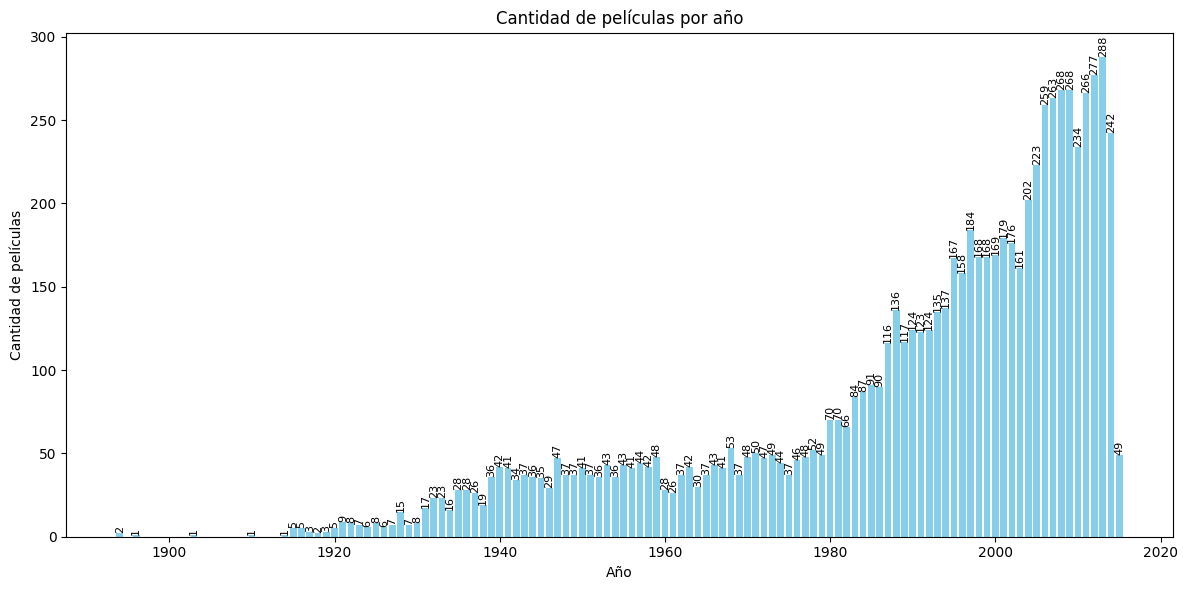


Longitud de 'plot':
- Mínima: 3
- Máxima: 9408
- Promedio: 748.82


In [45]:
analizar_data(dataTraining)

In [46]:
plot_lengths = dataTraining['plot'].dropna().apply(len)
std_plot_length = plot_lengths.std()

print(f"Desviación estándar de la longitud de 'plot': {std_plot_length:.2f}")

Desviación estándar de la longitud de 'plot': 494.77


In [47]:
dataTraining

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6
...,...,...,...,...,...
8417,2010,Our Family Wedding,""" our marriage , their wedding . "" it ' s l...","['Comedy', 'Romance']",4.9
1592,1984,Conan the Destroyer,"the wandering barbarian , conan , alongside ...","['Action', 'Adventure', 'Fantasy']",5.8
1723,1955,Kismet,"like a tale spun by scheherazade , kismet fol...","['Adventure', 'Musical', 'Fantasy', 'Comedy', ...",6.4
7605,1982,The Secret of NIMH,"mrs . brisby , a widowed mouse , lives in a...","['Animation', 'Adventure', 'Drama', 'Family', ...",7.6


## ANALISIS EXPLORATORIO

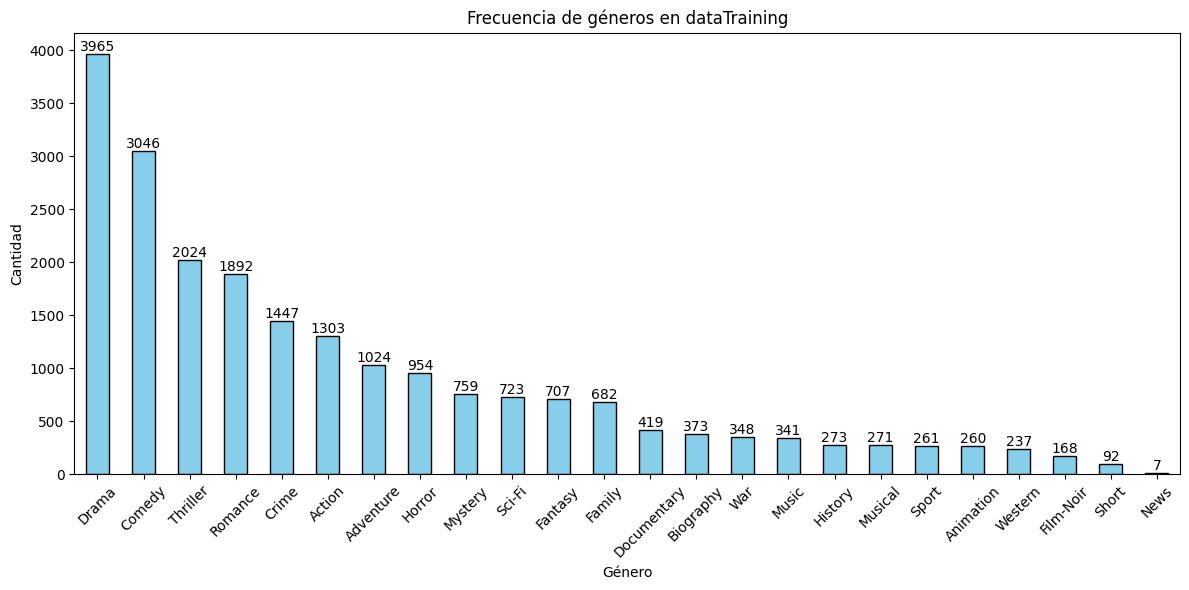

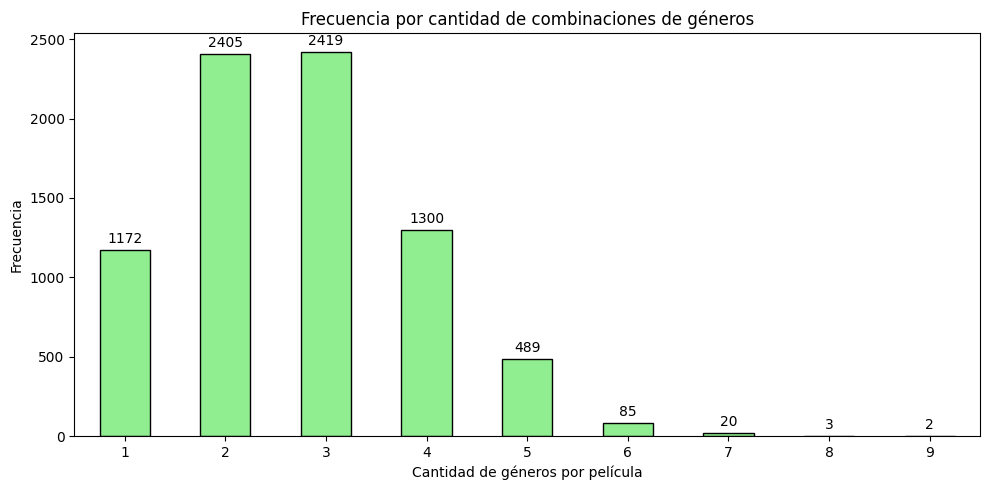

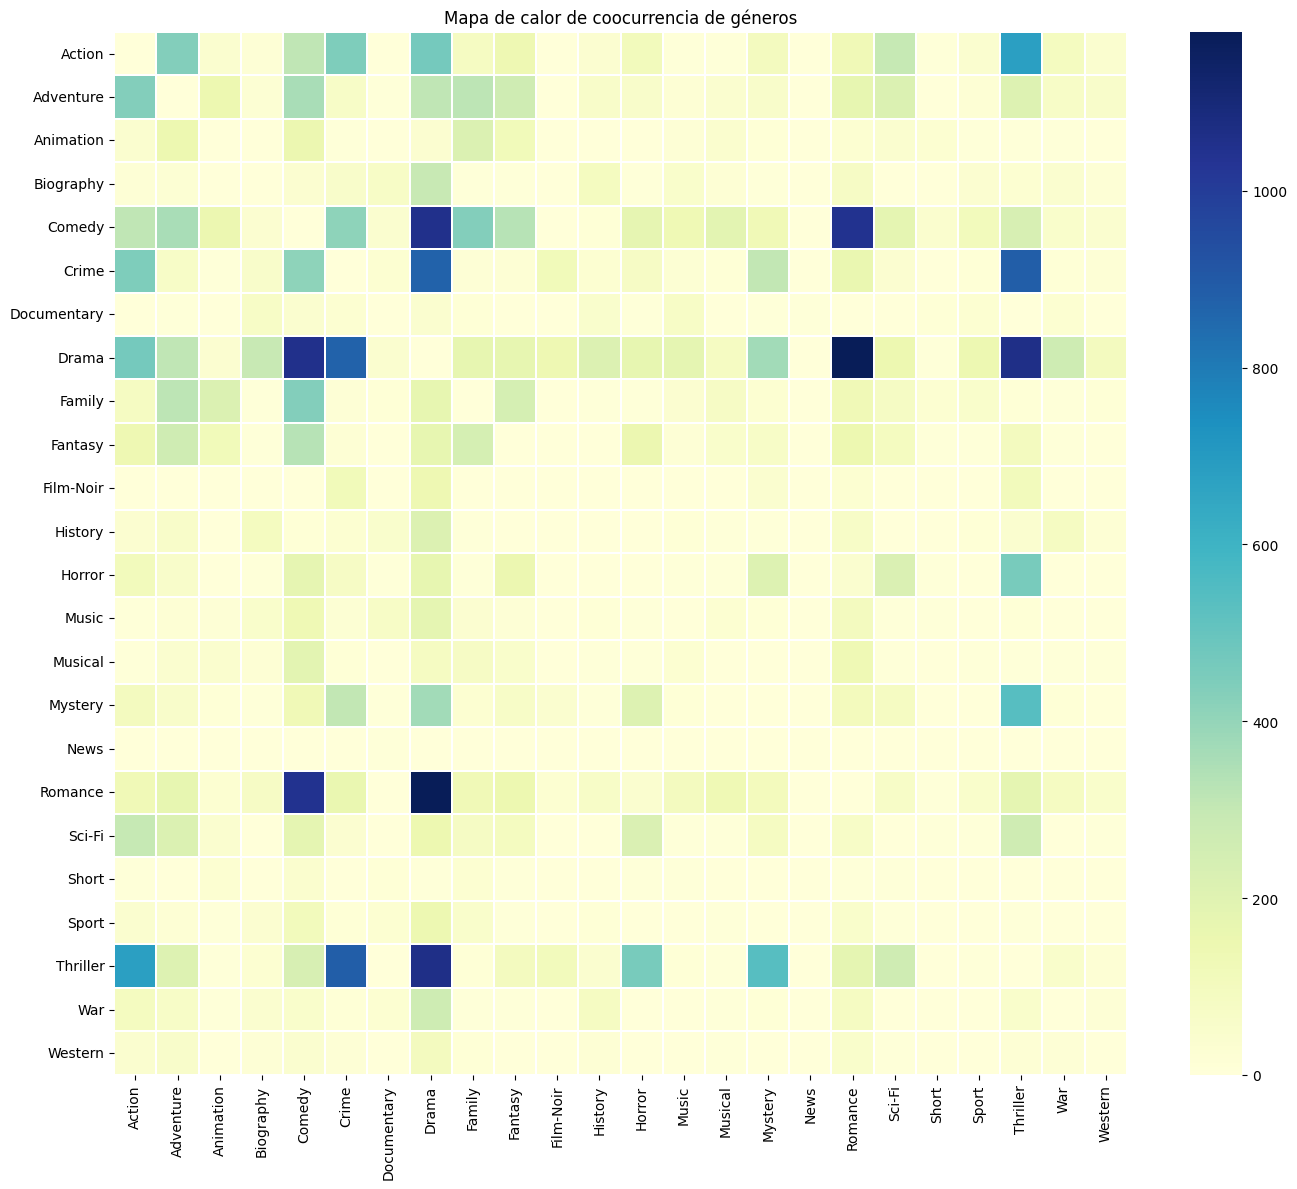

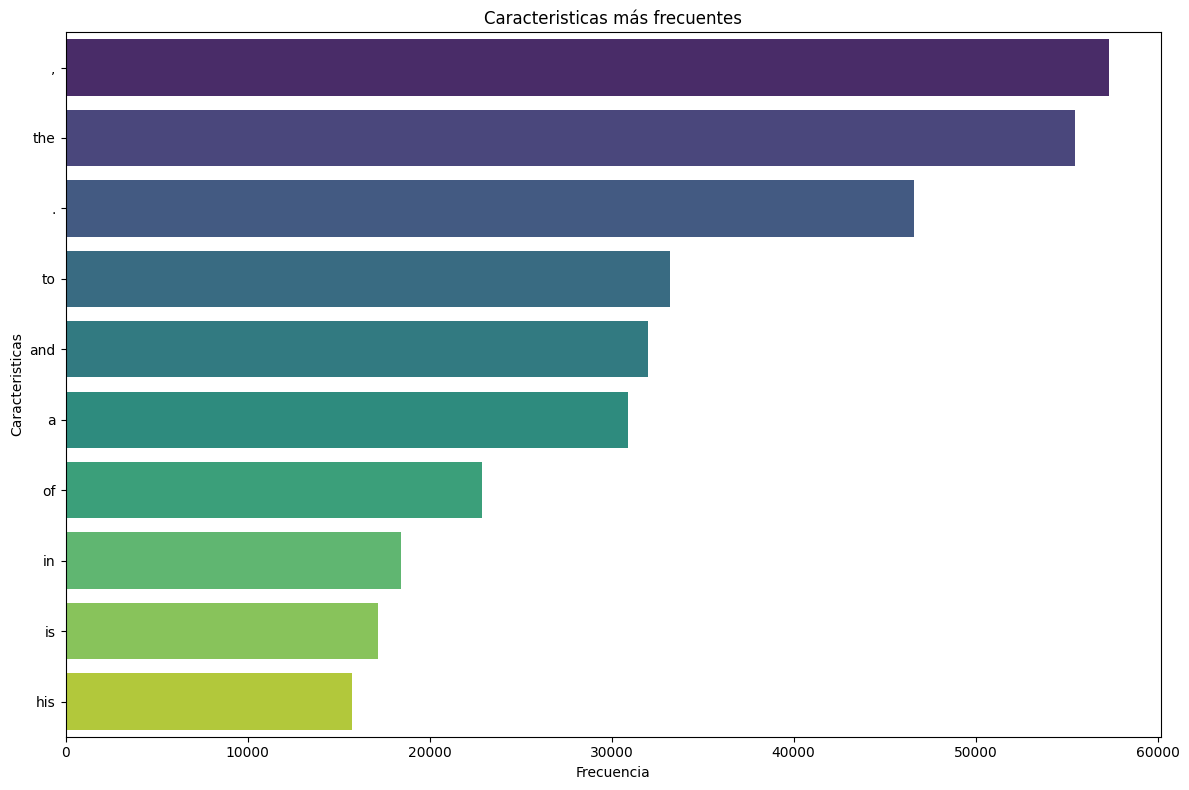

In [48]:
mapeo_frecuencia_genero(dataTraining)
print("\n")
frecuencia_por_combinaciones(dataTraining)
print("\n")
imprimir_mapa_calor(dataTraining)
print("\n")
freq_words(dataTraining['plot'], 10)

24 generos dentro de las posibles opciones a predecir.

Training data

0: Adventure-Action
1: Animation
2: Documentary
3: Film-Noir
4: History-War
5: Other
6: Sport
7: Thriller-Horror
8: Western




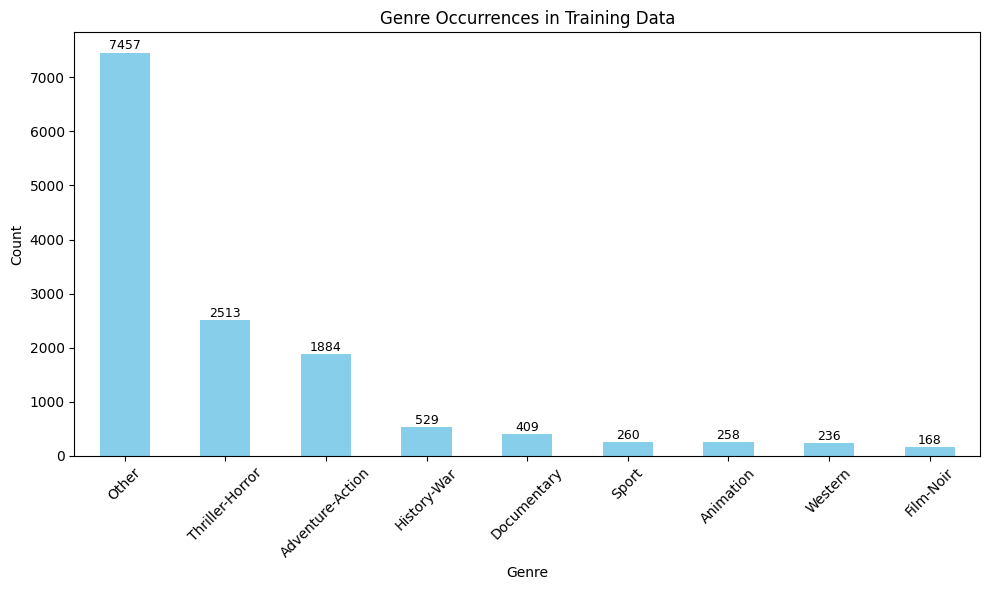

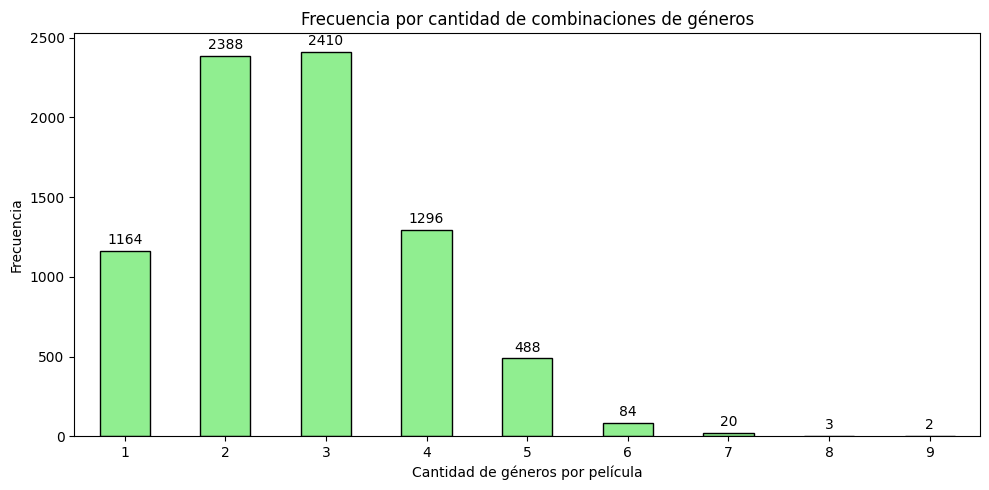

/tmp/ipykernel_1693/2133264068.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq.head(30), x='word', y='count', palette='viridis')


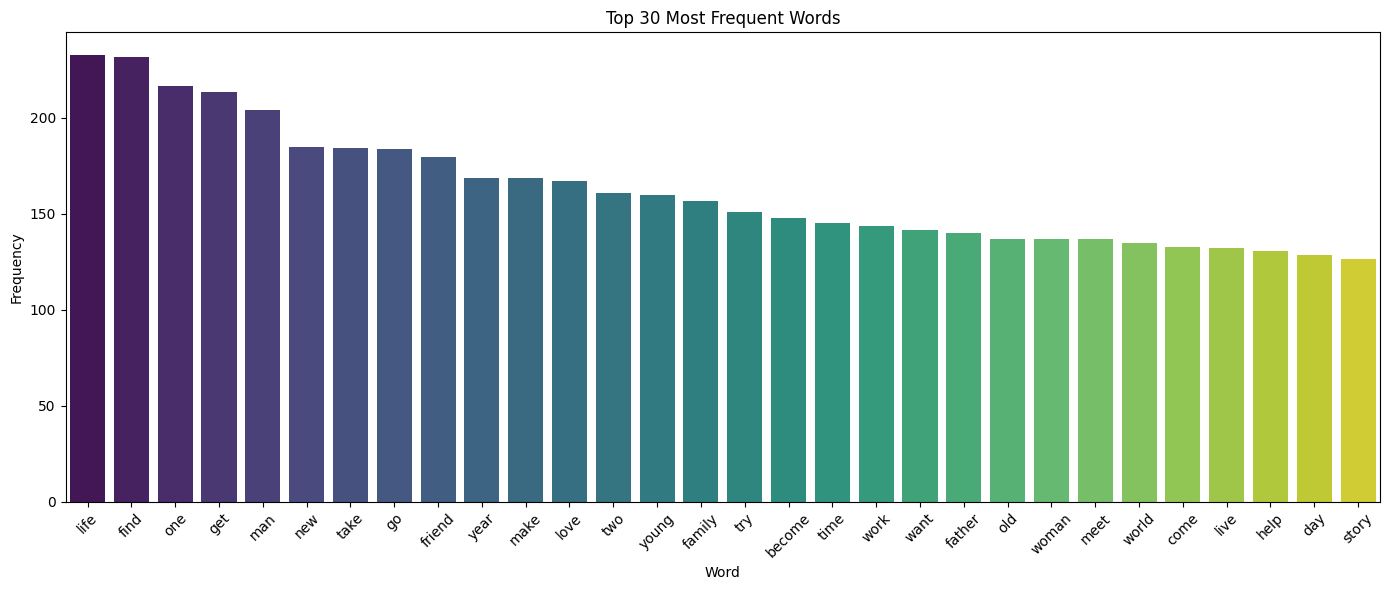

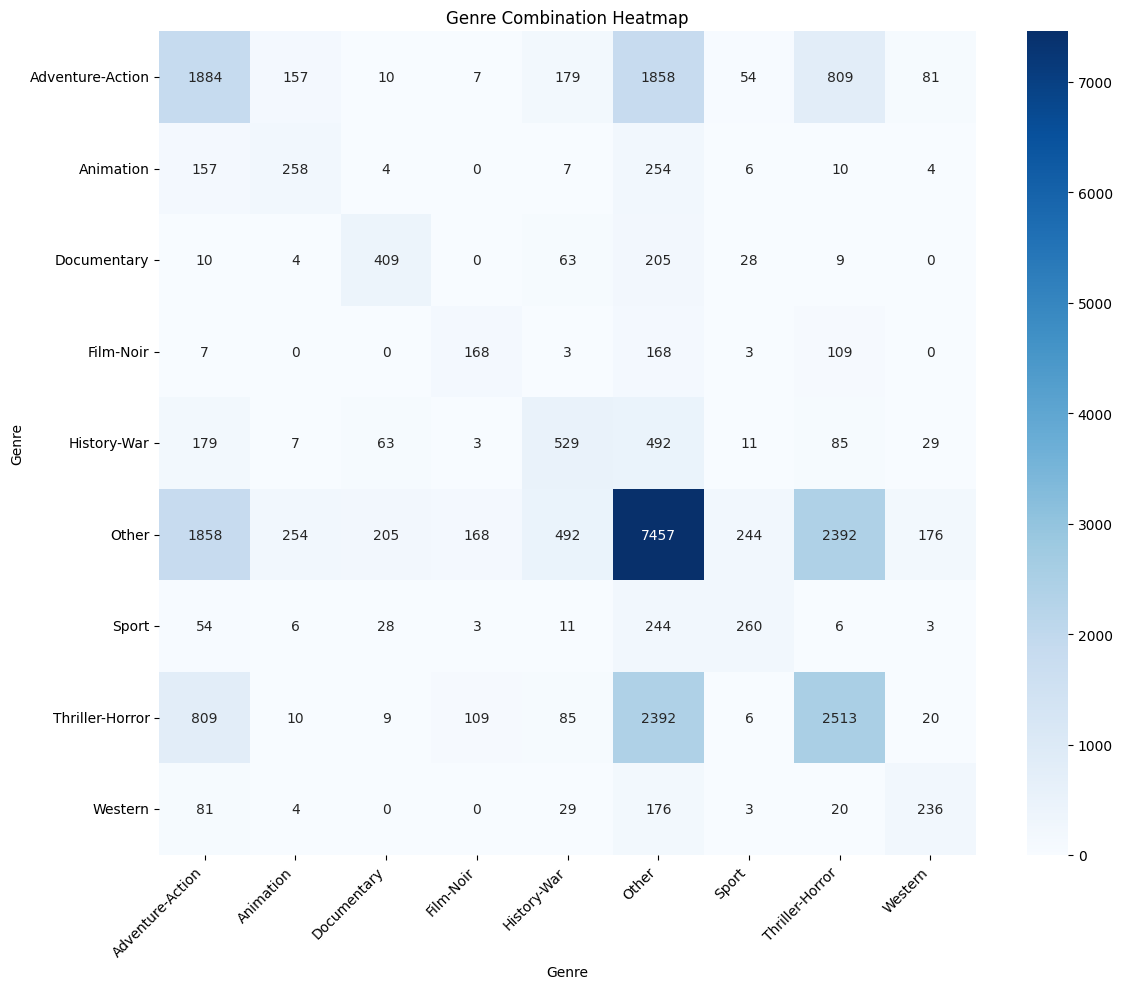



Nube de Palabras de los Plots


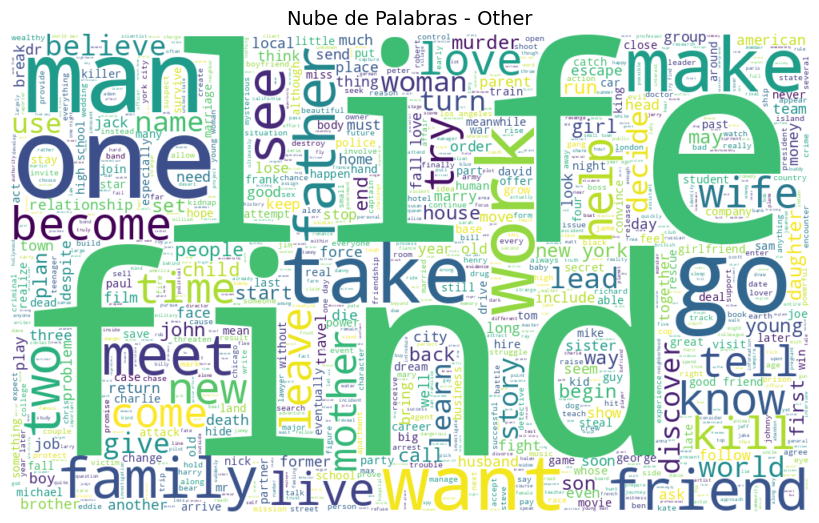

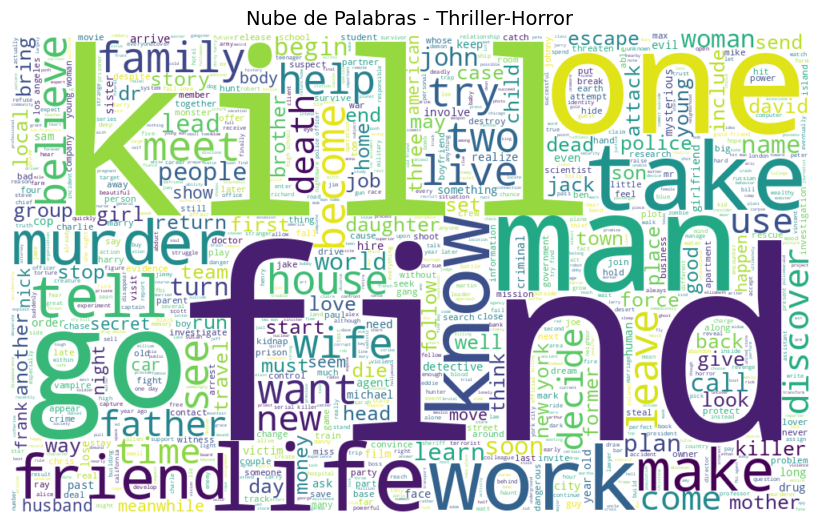

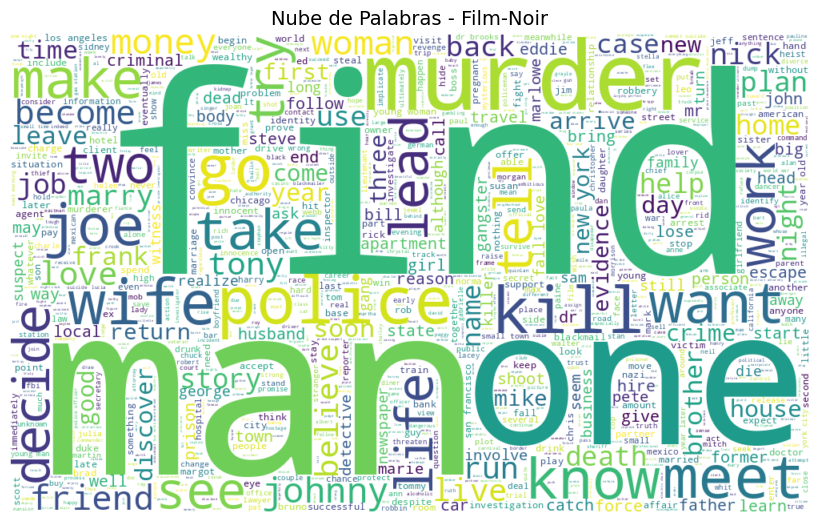

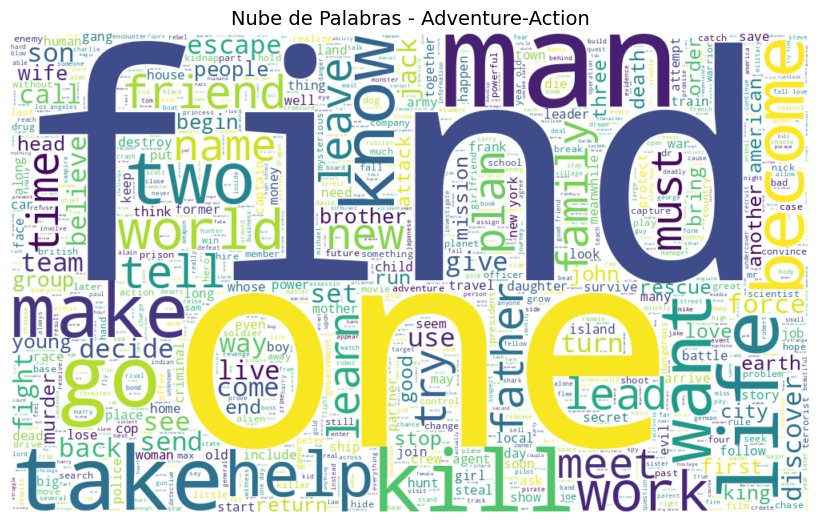

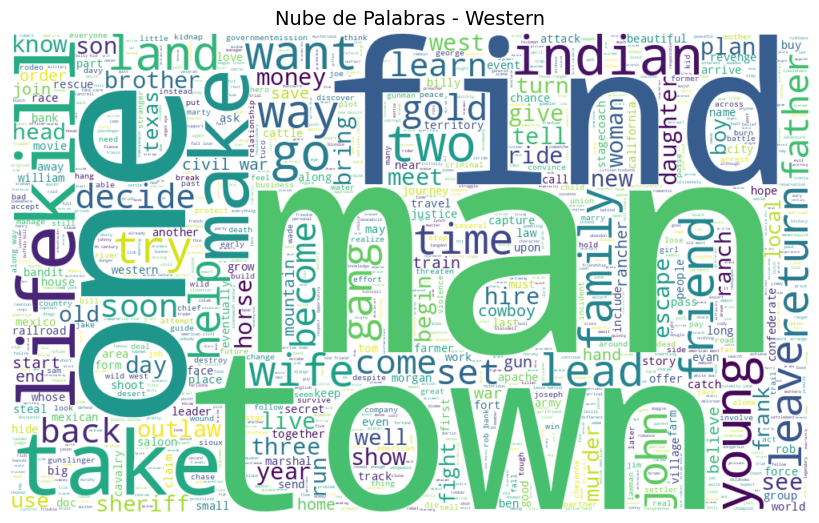

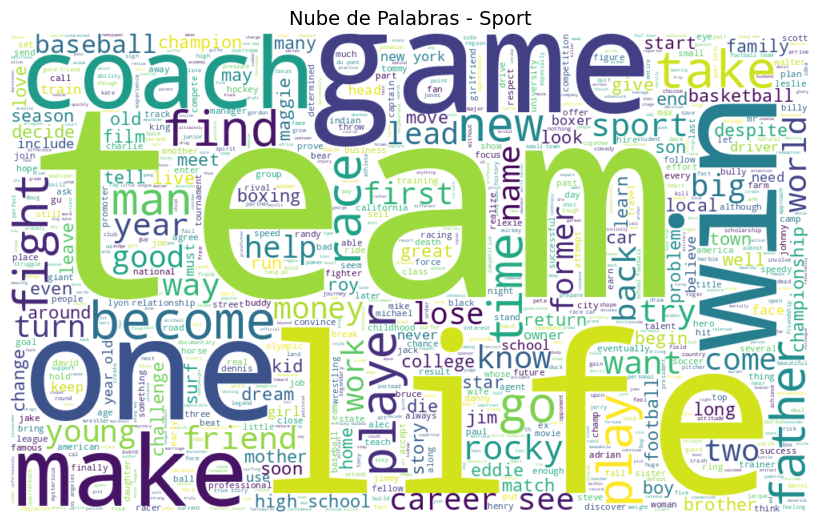

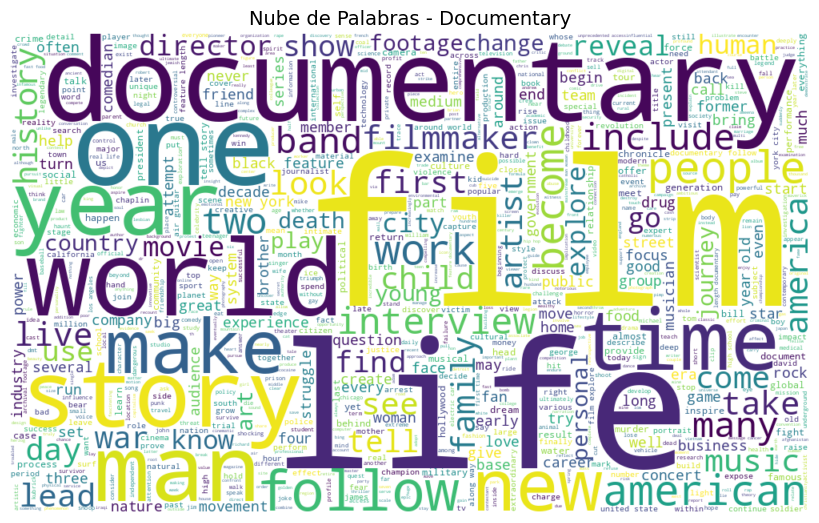

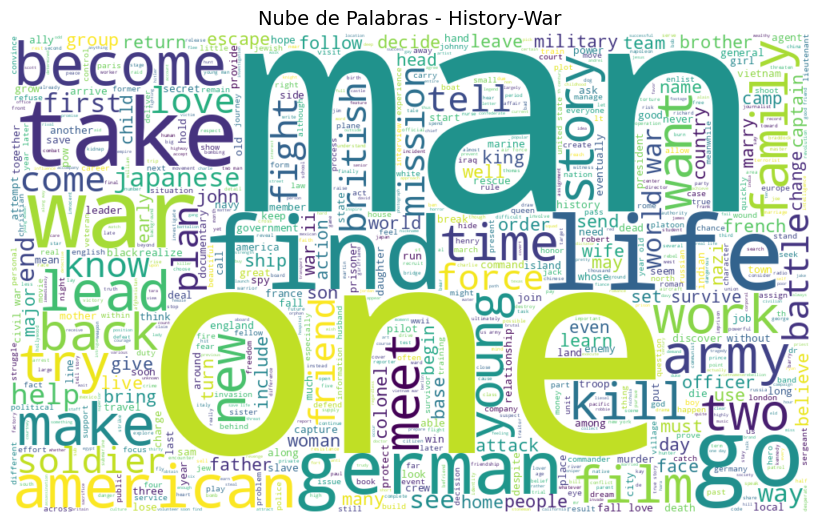

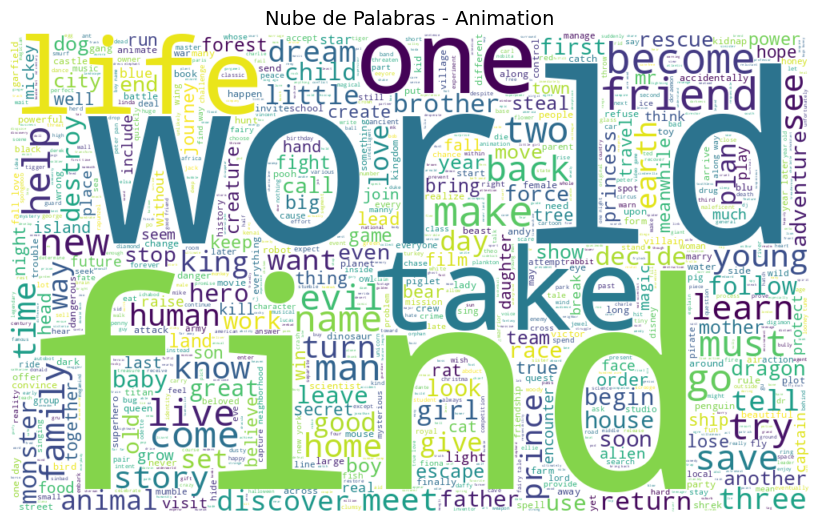



Validation data



,year,title,plot,clean_plot
0,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ....",meet fate shall seal fate theresa osborne run ...
1,1978,Midnight Express,"the true story of billy hayes , an american c...",true story billy haye american college student...
2,1996,Primal Fear,martin vail left the chicago da ' s office to ...,martin vail leave chicago da office become suc...
3,1950,Crisis,husband and wife americans dr . eugene and mr...,husband wife americans dr eugene mrs helen fer...
4,1959,The Tingler,the coroner and scientist dr . warren chapin ...,coroner scientist dr warren chapin research sh...
...,...,...,...,...
3366,2008,The Fifth Commandment,"in bangkok , an assassin who turns down a job...",bangkok assassin turn job hit close home find ...
3367,2003,Coffee and Cigarettes,eleven separate vignettes are presented . in ...,eleven separate vignette present celebrity pla...
3368,1957,Pal Joey,"joey evans is charming , handsome , funny , ...",joey evans charming handsome funny talented fi...
3369,2002,Jonah: A VeggieTales Movie,when the singing veggies encounter some car tr...,singing veggie encounter car trouble strand ol...


In [49]:
X_train, X_test, y_train_genres, y_test_genres, X_val, vect, dataTrainingP, dataTestingP = data_preprocessing(dataTraining, dataTesting)

# Random Forest

In [50]:
def create_model(trial):
    max_depth = trial.suggest_int("max_depth", 3, 15)
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    min_samples_split = trial.suggest_int("min_samples_split", 3, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 3, 20)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 10, 100)


    clf = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_leaf_nodes=max_leaf_nodes,
            n_jobs=-1,
            random_state=42
        ),
        n_jobs=-1
    )
    return clf

def objective(trial):
    global X_train, y_train_genres, X_test, y_test_genres 

    model = create_model(trial)
    model.fit(X_train, y_train_genres)

    y_train_pred = model.predict_proba(X_train)
    y_valid_pred = model.predict_proba(X_test)

    train_auc = roc_auc_score(y_train_genres, y_train_pred, average='macro')
    valid_auc = roc_auc_score(y_test_genres, y_valid_pred, average='macro')

    overFit = train_auc - valid_auc

    print(f"Train AUC: {np.mean(train_auc):.4f}, Validation AUC: {np.mean(valid_auc):.4f}")

    return valid_auc - overFit * 2

def main(n_trials):
    prune = optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=10,
        interval_steps=1
    )
    study = optuna.create_study(direction="maximize", pruner=prune)
    study.optimize(objective, n_trials=n_trials)

    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

    print("Study statistics: ")
    print("  Number of finished trials: ", len(study.trials))
    print("  Number of pruned trials: ", len(pruned_trials))
    print("  Number of complete trials: ", len(complete_trials))

    print("\nBest trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

    return trial

In [51]:
best_trial = main(100)

[I 2025-04-11 15:03:36,080] A new study created in memory with name: no-name-e6bfcc41-a63c-4e94-9cc4-4001ce2f2a5a



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/python3.10/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/pyt

Train AUC: 0.9102, Validation AUC: 0.8396



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/python3.10/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/home/lfrontuso/miniconda3/envs/cudf_env/lib/pyt

Train AUC: 0.9254, Validation AUC: 0.8405


...

Train AUC: 0.9406, Validation AUC: 0.8623


[I 2025-04-11 15:08:53,672] Trial 98 finished with value: 0.6993551003106834 and parameters: {'max_depth': 12, 'n_estimators': 112, 'max_features': 'log2', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_leaf_nodes': 12}. Best is trial 60 with value: 0.719131013231636.


Train AUC: 0.9381, Validation AUC: 0.8585


[I 2025-04-11 15:08:57,825] Trial 99 finished with value: 0.7080006952875015 and parameters: {'max_depth': 13, 'n_estimators': 164, 'max_features': 'log2', 'min_samples_split': 9, 'min_samples_leaf': 20, 'max_leaf_nodes': 16}. Best is trial 60 with value: 0.719131013231636.


Train AUC: 0.9404, Validation AUC: 0.8629
Study statistics: 
  Number of finished trials:  100
  Number of pruned trials:  0
  Number of complete trials:  100

Best trial:
  Value:  0.719131013231636
  Params: 
    max_depth: 12
    n_estimators: 165
    max_features: log2
    min_samples_split: 9
    min_samples_leaf: 20
    max_leaf_nodes: 11


[I 2025-04-07 23:51:52,834] Trial 94 finished with value: 0.8397558697668114 and parameters: {'max_depth': 12, 'n_estimators': 195, 'max_features': 'log2', 'min_samples_split': 7, 'min_samples_leaf': 18, 'max_leaf_nodes': 32}. Best is trial 94 with value: 0.8397558697668114.

In [52]:
def rfc(X_train, y_train_genres):

  clf = OneVsRestClassifier(
      RandomForestClassifier(
          n_estimators=184,
          max_depth=3,
          max_features="sqrt",
          min_samples_split=3,
          min_samples_leaf=20,
          max_leaf_nodes=10,
          n_jobs=-1,
          random_state=42
      ),
      n_jobs=-1
  )
  clf.fit(X_train, y_train_genres)

  return clf

clf = rfc(X_train, y_train_genres)

## Resultados del Random Forest

In [53]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf.predict_proba(X_train)
class_names = list(le.classes_)
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


precision_per_class = precision_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_train_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_train_genres, y_pred_genres_lr, average=None)

metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

print("#" * 5 + " Per-Class Metrics Train" + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_train_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Train#####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.947804  1.000000  0.973203  0.947804  0.876320
7   Thriller-Horror   1.000000  0.010956  0.021675  0.683959  0.827378
0  Adventure-Action   0.000000  0.000000  0.000000  0.757957  0.834448
1         Animation   0.000000  0.000000  0.000000  0.965468  0.917119
2       Documentary   0.000000  0.000000  0.000000  0.947645  0.949399
4       History-War   0.000000  0.000000  0.000000  0.931572  0.910853
3         Film-Noir   0.000000  0.000000  0.000000  0.978039  0.936241
6             Sport   0.000000  0.000000  0.000000  0.967218  0.926168
8           Western   0.000000  0.000000  0.000000  0.970401  0.956550

##### Global Metrics #####
Macro Precision: 0.2164
Macro Recall:    0.1123
Macro F1-Score:  0.1105
Macro AUC:  0.9038


In [54]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf.predict_proba(X_test)
class_names = list(le.classes_)
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


precision_per_class = precision_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_test_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_test_genres, y_pred_genres_lr, average=None)

metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

print("#" * 5 + " Per-Class Metrics Validation " + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_test_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Validation #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.955442  1.000000  0.977214  0.955442  0.753055
7   Thriller-Horror   1.000000  0.009901  0.019608  0.681731  0.807411
0  Adventure-Action   0.000000  0.000000  0.000000  0.768937  0.805571
1         Animation   0.000000  0.000000  0.000000  0.973902  0.776367
2       Documentary   0.000000  0.000000  0.000000  0.949077  0.922464
4       History-War   0.000000  0.000000  0.000000  0.936983  0.856260
3         Film-Noir   0.000000  0.000000  0.000000  0.980904  0.861800
6             Sport   0.000000  0.000000  0.000000  0.965627  0.898423
8           Western   0.000000  0.000000  0.000000  0.968173  0.868008

##### Global Metrics #####
Macro Precision: 0.2173
Macro Recall:    0.1122
Macro F1-Score:  0.1108
Macro AUC:  0.8388


# Regresón Logistica

In [55]:
def create_model(trial):

  l1_ratio = trial.suggest_float("l1_ratio", 0, 1)
  c = trial.suggest_float("c", 0, 2)

  model = OneVsRestClassifier(
        LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=l1_ratio,
        C=c,
        max_iter=250,
        n_jobs=-1
    ),
    n_jobs=-1
  )

  return model

def objective(trial):
    global X_train, y_train_genres, X_test, y_test_genres  

    model = create_model(trial)
    model.fit(X_train, y_train_genres)

    y_train_pred = model.predict_proba(X_train)
    y_valid_pred = model.predict_proba(X_test)

    train_auc = roc_auc_score(y_train_genres, y_train_pred, average='macro')
    valid_auc = roc_auc_score(y_test_genres, y_valid_pred, average='macro')

    overFit = train_auc - valid_auc

    print(f"Train AUC: {np.mean(train_auc):.4f}, Validation AUC: {np.mean(valid_auc):.4f}")

    return valid_auc - overFit * 1.5

def main(n_trials):
    prune = optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=10,
            interval_steps=1
        )
    study = optuna.create_study(direction="maximize", pruner=prune)
    study.optimize(objective, n_trials=n_trials)
    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    print("Study statistics: ")
    print("  Number of finished trials: ", len(study.trials))
    print("  Number of pruned trials: ", len(pruned_trials))
    print("  Number of complete trials: ", len(complete_trials))

    print("\nBest trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    return trial

In [56]:
best_trial = main(100)

[I 2025-04-11 15:09:01,947] A new study created in memory with name: no-name-e86f4936-ba81-4470-be16-91e9ebc28fb5
[I 2025-04-11 15:09:05,420] Trial 0 finished with value: 0.8172416153163912 and parameters: {'l1_ratio': 0.12212253449503019, 'c': 0.6692157948698065}. Best is trial 0 with value: 0.8172416153163912.


Train AUC: 0.9507, Validation AUC: 0.8973


[I 2025-04-11 15:09:06,154] Trial 1 finished with value: 0.6661053846495056 and parameters: {'l1_ratio': 0.9606061453431222, 'c': 0.16557099249042273}. Best is trial 0 with value: 0.8172416153163912.


Train AUC: 0.6926, Validation AUC: 0.6820


[I 2025-04-11 15:09:07,154] Trial 2 finished with value: 0.815920211661636 and parameters: {'l1_ratio': 0.33357631025833734, 'c': 0.1673664258357881}. Best is trial 0 with value: 0.8172416153163912.


...

Train AUC: 0.9379, Validation AUC: 0.8941


[I 2025-04-11 15:12:46,828] Trial 98 finished with value: 0.8343714463941827 and parameters: {'l1_ratio': 0.024101628338876982, 'c': 0.09956135494969903}. Best is trial 64 with value: 0.8358731965500402.


Train AUC: 0.9299, Validation AUC: 0.8917


[I 2025-04-11 15:12:50,150] Trial 99 finished with value: 0.808848500576884 and parameters: {'l1_ratio': 0.2392544595860041, 'c': 0.9518687190555434}. Best is trial 64 with value: 0.8358731965500402.


Train AUC: 0.9525, Validation AUC: 0.8951
Study statistics: 
  Number of finished trials:  100
  Number of pruned trials:  0
  Number of complete trials:  100

Best trial:
  Value:  0.8358731965500402
  Params: 
    l1_ratio: 0.0015130997241724967
    c: 0.0044653835705846245


[I 2025-04-08 02:09:14,261] Trial 43 finished with value: 0.8173380044594953 and parameters: {'l1_ratio': 0.11398855176756906, 'c': 0.4058035200843805}. Best is trial 42 with value: 0.8229122952029246.
Train AUC: 0.9402, Validation AUC: 0.8911

In [57]:
def lr(X_train, y_train_genres):

  clf = OneVsRestClassifier(
        LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.11398855176756906,   # 0.5 = 50% L1, 50% L2
        C=0.4058035200843805,
        max_iter=1000
    ),
    n_jobs=-1
  )
  clf.fit(X_train, y_train_genres)
  return clf
clf1 = lr(X_train, y_train_genres)

## Resultados de la Regresión Logistica

In [58]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf1.predict_proba(X_train)
class_names = list(le.classes_)
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


precision_per_class = precision_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_train_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_train_genres, y_pred_genres_lr, average=None)

metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

print("#" * 5 + " Per-Class Metrics Train" + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_train_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Train#####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.948399  0.999832  0.973437  0.948281  0.910580
7   Thriller-Horror   0.838392  0.508964  0.633406  0.811744  0.896860
0  Adventure-Action   0.856667  0.337936  0.484677  0.826066  0.899926
2       Documentary   0.935484  0.176292  0.296675  0.956238  0.977710
4       History-War   0.857143  0.097674  0.175365  0.937142  0.949009
6             Sport   1.000000  0.029126  0.056604  0.968173  0.960584
1         Animation   0.000000  0.000000  0.000000  0.965468  0.953853
3         Film-Noir   0.000000  0.000000  0.000000  0.978039  0.940500
8           Western   0.000000  0.000000  0.000000  0.970401  0.973403

##### Global Metrics #####
Macro Precision: 0.6040
Macro Recall:    0.2389
Macro F1-Score:  0.2911
Macro AUC:  0.9403


In [59]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf1.predict_proba(X_test)
class_names = list(le.classes_)
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)

precision_per_class = precision_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_test_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_test_genres, y_pred_genres_lr, average=None)

metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

print("#" * 5 + " Per-Class Metrics Validation " + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_test_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Validation #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.956660  1.000000  0.977850  0.956715  0.819796
7   Thriller-Horror   0.774920  0.477228  0.590686  0.787397  0.864540
0  Adventure-Action   0.789474  0.289256  0.423387  0.817950  0.858277
2       Documentary   1.000000  0.175000  0.297872  0.957989  0.960027
4       History-War   0.909091  0.101010  0.181818  0.942712  0.893150
6             Sport   1.000000  0.018519  0.036364  0.966264  0.940050
1         Animation   0.000000  0.000000  0.000000  0.973902  0.875100
3         Film-Noir   0.000000  0.000000  0.000000  0.980904  0.922648
8           Western   0.000000  0.000000  0.000000  0.968173  0.914267

##### Global Metrics #####
Macro Precision: 0.6033
Macro Recall:    0.2290
Macro F1-Score:  0.2787
Macro AUC:  0.8942


## METRICA CONSEGUIDA: 
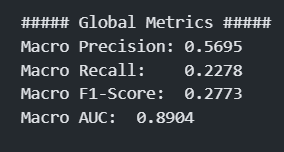

#Multinomial Naive Bayes

In [60]:
from sklearn.naive_bayes import MultinomialNB
nb_classifier = OneVsRestClassifier(MultinomialNB()) 
nb_classifier.fit(X_train, y_train_genres)

OneVsRestClassifier(estimator=MultinomialNB())

## Resultados del modelo Multinomial Naive Bayes

In [61]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = nb_classifier.predict_proba(X_train)
class_names = list(le.classes_)
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)

precision_per_class = precision_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_train_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_train_genres, y_pred_genres_lr, average=None)

metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

print("#" * 5 + " Per-Class Metrics Train" + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_train_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Train#####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.947804  1.000000  0.973203  0.947804  0.900280
7   Thriller-Horror   0.815969  0.417331  0.552224  0.783736  0.880438
0  Adventure-Action   0.819728  0.316897  0.457089  0.817791  0.878532
2       Documentary   0.982759  0.173252  0.294574  0.956556  0.976827
4       History-War   0.933333  0.097674  0.176842  0.937778  0.944619
6             Sport   1.000000  0.029126  0.056604  0.968173  0.963979
1         Animation   0.000000  0.000000  0.000000  0.965468  0.950412
3         Film-Noir   0.000000  0.000000  0.000000  0.978039  0.921106
8           Western   0.000000  0.000000  0.000000  0.970401  0.960367

##### Global Metrics #####
Macro Precision: 0.6111
Macro Recall:    0.2260
Macro F1-Score:  0.2789
Macro AUC:  0.9307


In [62]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = nb_classifier.predict_proba(X_test)
class_names = list(le.classes_)
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)

precision_per_class = precision_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_test_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_test_genres, y_pred_genres_lr, average=None)

metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

print("#" * 5 + " Per-Class Metrics Validation " + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_test_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Validation #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.955442  1.000000  0.977214  0.955442  0.812278
7   Thriller-Horror   0.800000  0.388119  0.522667  0.772120  0.862452
0  Adventure-Action   0.807407  0.300275  0.437751  0.821770  0.857627
4       History-War   0.857143  0.121212  0.212389  0.943348  0.891682
2       Documentary   1.000000  0.100000  0.181818  0.954169  0.957797
3         Film-Noir   0.000000  0.000000  0.000000  0.980904  0.854056
1         Animation   0.000000  0.000000  0.000000  0.973902  0.843026
6             Sport   0.000000  0.000000  0.000000  0.965627  0.887265
8           Western   0.000000  0.000000  0.000000  0.968173  0.913465

##### Global Metrics #####
Macro Precision: 0.4911
Macro Recall:    0.2122
Macro F1-Score:  0.2591
Macro AUC:  0.8755


## ENSAMBLES 

In [63]:
generos = [
    'Adventure-Action', 'Animation', 'Documentary', 'Film-Noir',
    'History-War', 'Other', 'Sport', 'Thriller-Horror', 'Western'
]

In [64]:
seed = 42
rng = np.random.default_rng(seed)

modelos = {}
f1_scores = {}

for i, genero in enumerate(generos):
    print(f"Género: {genero}")
    
    y = y_train_genres[:, i]
    positivos_idx = np.where(y == 1)[0]
    negativos_idx = np.where(y == 0)[0]

    n_positivos = len(positivos_idx)
    n_negativos = len(negativos_idx)

    print(f"  → Positivos: {n_positivos}")
    print(f"  → Negativos: {n_negativos}")

    if n_positivos < 400:
        print("  → Aplicando Leave-One-Out para evaluación")
        print(f"  → Nueva cantidad de negativos: {n_negativos}")
        
        y_true, y_pred = [], []

        loo = LeaveOneOut()
        for train_idx, test_idx in loo.split(positivos_idx):
            pos_train = positivos_idx[train_idx]
            pos_test = positivos_idx[test_idx]

            combined_train_idx = np.concatenate([pos_train, negativos_idx])
            combined_test_idx = pos_test

            if genero == "Other":
                modelo_temp = LogisticRegression(max_iter=2000)
            else:
                modelo_temp = LogisticRegression(max_iter=2000, class_weight='balanced')

            modelo_temp.fit(X_train[combined_train_idx], y[combined_train_idx])
            
            y_pred.append(modelo_temp.predict(X_train[combined_test_idx])[0])
            y_true.append(y[combined_test_idx][0])

        f1 = f1_score(y_true, y_pred)
        f1_scores[genero] = f1
        print(f"  → F1 Score (LOO): {f1:.4f}")

        final_idx = np.concatenate([positivos_idx, negativos_idx])
        
        if genero == "Other":
            modelo_final = LogisticRegression(max_iter=2000)
        else:
            modelo_final = LogisticRegression(max_iter=2000)

        modelo_final.fit(X_train[final_idx], y[final_idx])
        modelos[genero] = modelo_final

    else:
        print("  → Entrenando y evaluando con KFold=5")        
        n_negativos_requeridos = int(n_positivos * 0.40)
        
        if n_negativos < n_negativos_requeridos:
            print(f"  Solo hay {n_negativos} negativos disponibles. Usando todos.")
            selected_negativos = negativos_idx
            nueva_cantidad_negativos = len(selected_negativos)
        else:
            selected_negativos = rng.choice(negativos_idx, size=n_negativos_requeridos, replace=False)
            nueva_cantidad_negativos = n_negativos_requeridos
        
        print(f"  → Nueva cantidad de negativos: {nueva_cantidad_negativos}")
        
        subset_idx = np.concatenate([positivos_idx, selected_negativos])
        X_subset = X_train[subset_idx]
        y_subset = y[subset_idx]
        
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        y_true_kfold, y_pred_kfold = [], []
        
        for train_idx, test_idx in kf.split(X_subset):
            X_train_fold, X_test_fold = X_subset[train_idx], X_subset[test_idx]
            y_train_fold, y_test_fold = y_subset[train_idx], y_subset[test_idx]
            
            if genero == "Other":
                modelo_fold = LogisticRegression(max_iter=2000)
            else:
                modelo_fold = LogisticRegression(max_iter=2000, class_weight='balanced')
            
            modelo_fold.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = modelo_fold.predict(X_test_fold)
            y_true_kfold.extend(y_test_fold)
            y_pred_kfold.extend(y_pred_fold)
        
        f1 = f1_score(y_true_kfold, y_pred_kfold)
        f1_scores[genero] = f1
        print(f"  → F1 Score (KFold=5): {f1:.4f}")
        
        if genero == "Other":
            modelo_final = LogisticRegression(max_iter=2000)
        else:
            modelo_final = LogisticRegression(max_iter=2000, class_weight='balanced')

        modelo_final.fit(X_subset, y_subset)
        modelos[genero] = modelo_final

print("\nF1 Scores para todos los géneros:")
for genero, score in f1_scores.items():
    print(f"  - {genero}: {score:.4f}")


Género: Adventure-Action
  → Positivos: 1521
  → Negativos: 4763
  → Entrenando y evaluando con KFold=5
  → Nueva cantidad de negativos: 608


  → F1 Score (KFold=5): 0.8421
Género: Animation
  → Positivos: 217
  → Negativos: 6067
  → Aplicando Leave-One-Out para evaluación
  → Nueva cantidad de negativos: 6067
  → F1 Score (LOO): 0.7384
Género: Documentary
  → Positivos: 329
  → Negativos: 5955
  → Aplicando Leave-One-Out para evaluación
  → Nueva cantidad de negativos: 5955
  → F1 Score (LOO): 0.8714
Género: Film-Noir
  → Positivos: 138
  → Negativos: 6146
  → Aplicando Leave-One-Out para evaluación
  → Nueva cantidad de negativos: 6146
  → F1 Score (LOO): 0.6471
Género: History-War
  → Positivos: 430
  → Negativos: 5854
  → Entrenando y evaluando con KFold=5
  → Nueva cantidad de negativos: 172
  → F1 Score (KFold=5): 0.8700
Género: Other
  → Positivos: 5956
  → Negativos: 328
  → Entrenando y evaluando con KFold=5
  Solo hay 328 negativos disponibles. Usando todos.
  → Nueva cantidad de negativos: 328
  → F1 Score (KFold=5): 0.9733
Género: Sport
  → Positivos: 206
  → Negativos: 6078
  → Aplicando Leave-One-Out para evalu

In [65]:
train_aucs = []
test_aucs = []

print("Evaluación de AUC por género:\n")

for i, genero in enumerate(modelos):
    modelo = modelos[genero]

    y_train_proba = modelo.predict_proba(X_train)[:, 1]
    y_test_proba = modelo.predict_proba(X_test)[:, 1]

    y_train_true = y_train_genres[:, i]
    y_test_true = y_test_genres[:, i]

    try:
        auc_train = roc_auc_score(y_train_true, y_train_proba)
    except ValueError:
        auc_train = float('nan')  

    try:
        auc_test = roc_auc_score(y_test_true, y_test_proba)
    except ValueError:
        auc_test = float('nan')  

    train_aucs.append(auc_train)
    test_aucs.append(auc_test)

    print(f"{genero}")
    print(f"  - AUC TRAIN: {auc_train:.4f}")
    print(f"  - AUC TEST : {auc_test:.4f}\n")

avg_train_auc = np.nanmean(train_aucs)
avg_test_auc = np.nanmean(test_aucs)

print("=== Promedio de AUC ===")
print(f"  - AUC PROMEDIO TRAIN: {avg_train_auc:.4f}")
print(f"  - AUC PROMEDIO TEST : {avg_test_auc:.4f}")

Evaluación de AUC por género:

Adventure-Action
  - AUC TRAIN: 0.8857
  - AUC TEST : 0.8445

Animation
  - AUC TRAIN: 0.9755
  - AUC TEST : 0.8815

Documentary
  - AUC TRAIN: 0.9876
  - AUC TEST : 0.9649

Film-Noir
  - AUC TRAIN: 0.9748
  - AUC TEST : 0.9315

History-War
  - AUC TRAIN: 0.9468
  - AUC TEST : 0.8800

Other
  - AUC TRAIN: 0.9450
  - AUC TEST : 0.8342

Sport
  - AUC TRAIN: 0.9833
  - AUC TEST : 0.9479

Thriller-Horror
  - AUC TRAIN: 0.8825
  - AUC TEST : 0.8420

Western
  - AUC TRAIN: 0.9884
  - AUC TEST : 0.9331

=== Promedio de AUC ===
  - AUC PROMEDIO TRAIN: 0.9522
  - AUC PROMEDIO TEST : 0.8955


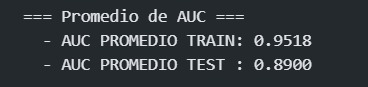

In [66]:
dataTrainingP

,year,title,plot,genres,rating,genres_list,num_genres,clean_plot,grouped_genres
0,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0,"[Short, Drama]",2,story single father take eight year old son wo...,[Other]
1,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6,"[Comedy, Crime, Horror]",3,serial killer decide teach secret satisfying c...,"[Thriller-Horror, Other]"
2,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2,"[Drama, Film-Noir, Thriller]",3,sweden female blackmailer disfiguring facial s...,"[Thriller-Horror, Other, Film-Noir]"
3,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4,[Drama],1,friday afternoon new york president tredway co...,[Other]
4,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6,"[Action, Crime, Thriller]",3,los angeles editor publishing house carol hunn...,"[Adventure-Action, Thriller-Horror, Other]"
...,...,...,...,...,...,...,...,...,...
7850,2010,Our Family Wedding,""" our marriage , their wedding . "" it ' s l...","['Comedy', 'Romance']",4.9,"[Comedy, Romance]",2,marriage wedding lesson number one newly engag...,[Other]
7851,1984,Conan the Destroyer,"the wandering barbarian , conan , alongside ...","['Action', 'Adventure', 'Fantasy']",5.8,"[Action, Adventure, Fantasy]",3,wandering barbarian conan alongside goofy rogu...,"[Adventure-Action, Other]"
7852,1955,Kismet,"like a tale spun by scheherazade , kismet fol...","['Adventure', 'Musical', 'Fantasy', 'Comedy', ...",6.4,"[Adventure, Musical, Fantasy, Comedy, Romance]",5,like tale spin scheherazade kismet follow rema...,"[Adventure-Action, Other]"
7853,1982,The Secret of NIMH,"mrs . brisby , a widowed mouse , lives in a...","['Animation', 'Adventure', 'Drama', 'Family', ...",7.6,"[Animation, Adventure, Drama, Family, Fantasy,...",6,mrs brisby widow mouse live cinder block child...,"[Animation, Other, Adventure-Action]"


In [67]:
def predecir_todas_las_probabilidades(plot, vect, modelos):
    X_new = vect.transform([plot])
    
    resultados = {}

    for genero, modelo in modelos.items():
        prob = modelo.predict_proba(X_new)[0][1] 
        resultados[genero] = prob

    valores_prob = list(resultados.values())
    media = np.mean(valores_prob)
    std = np.std(valores_prob)
    umbral_dinamico = media + std

    return resultados, umbral_dinamico


plot_nuevo = """
tinker bell journey far north of never land to patch things up with her friend terence and restore a pixie dust tree .
"""

resultado, umbral = predecir_todas_las_probabilidades(plot_nuevo, vect, modelos)

print("Probabilidades de todos los géneros:\n")
for genero, prob in resultado.items():
    print(f"{genero}: {prob:.2f}")

generos_predichos = [genero for genero, prob in resultado.items() if prob >= umbral]

print(f"\nUmbral dinámico (media + std): {umbral:.2f}")
print("\nGénero(s) final(es) predicho(s):")
if generos_predichos:
    for genero in generos_predichos:
        print(f"- {genero}")
else:
    print("Ningún género alcanzó el umbral dinámico.")


Probabilidades de todos los géneros:

Adventure-Action: 0.62
Animation: 0.11
Documentary: 0.11
Film-Noir: 0.01
History-War: 0.56
Other: 0.83
Sport: 0.02
Thriller-Horror: 0.15
Western: 0.12

Umbral dinámico (media + std): 0.57

Género(s) final(es) predicho(s):
- Adventure-Action
- Other
